In [32]:
# ejemplo de RF en la clasificacion
# se usa el conjunto de datos Iris para clasificar flores
# en tres especies diferentes

In [33]:
# Importar las bibliotecas necesarias
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
# Cargar el conjunto de datos Iris
# son caracteristicas de flores y respectiva clasificacion
iris = load_iris()
X = iris.data
y = iris.target

In [35]:
# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Crear y entrenar el modelo de Random Forest, con 100 arboles
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
# Realizar predicciones
y_pred = rf.predict(X_test)

In [38]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud: {accuracy:.2f}")

Exactitud: 1.00


In [39]:
# Informe de clasificación
print("Informe de clasificación:\n", classification_report(y_test, y_pred))

Informe de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [40]:
# Matriz de confusión
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

Matriz de confusión:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [41]:
# graficando
# para graficar 100 arboles muy complicado, vamos seleccionando algunos
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

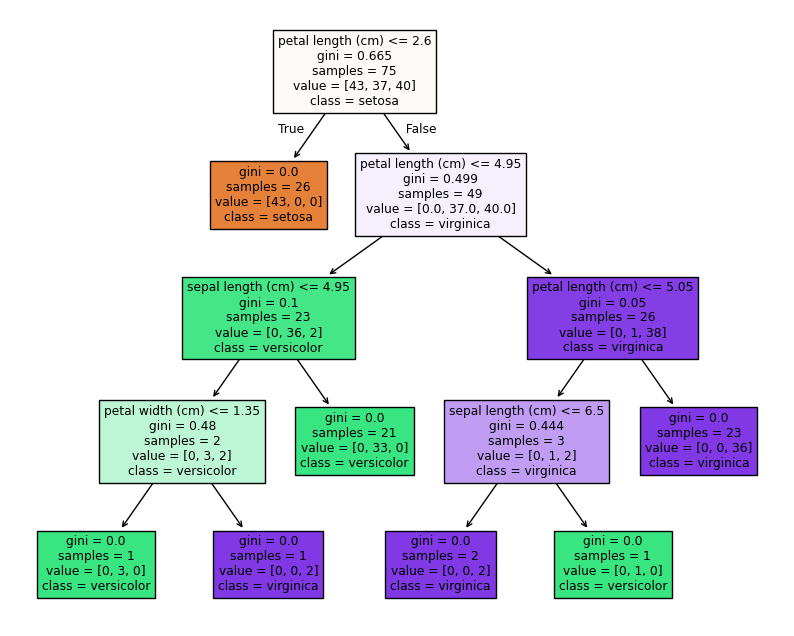

In [42]:
# Seleccionar el primer árbol del conjunto
tree = rf.estimators_[1]
# Graficar el árbol
plt.figure(figsize=(10,8))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [43]:
# Seleccionar el siguiente árbol del conjunto
tree = rf.estimators_[1]

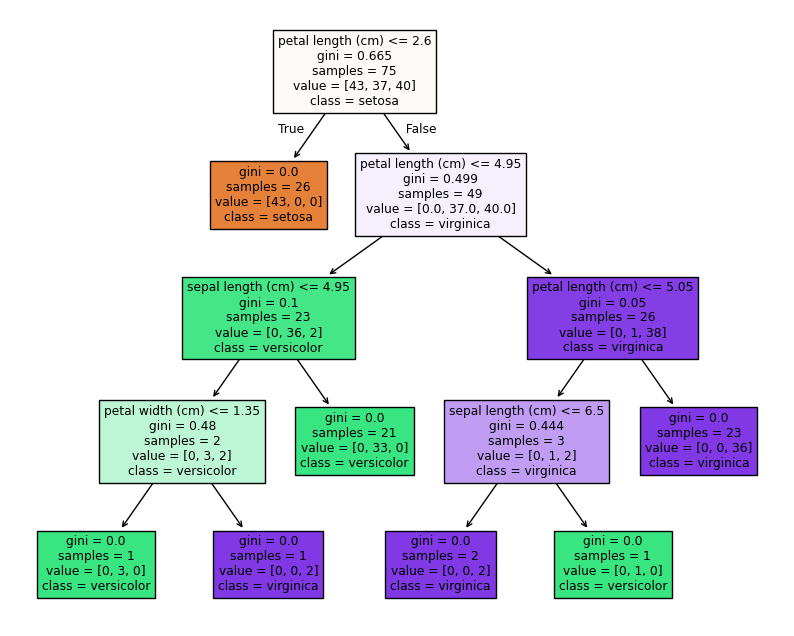

In [44]:
# Graficar el siguiente árbol
plt.figure(figsize=(10,8))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [45]:
# para visualizar las predicciones, se usa un grafico de dispersion
# las observaciones se colorean segun su clase real y predicha
# si las clases se separan bien en ambas grafica
# indica que el modelo esta funcionando

In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [47]:
# Reducir la dimensionalidad a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

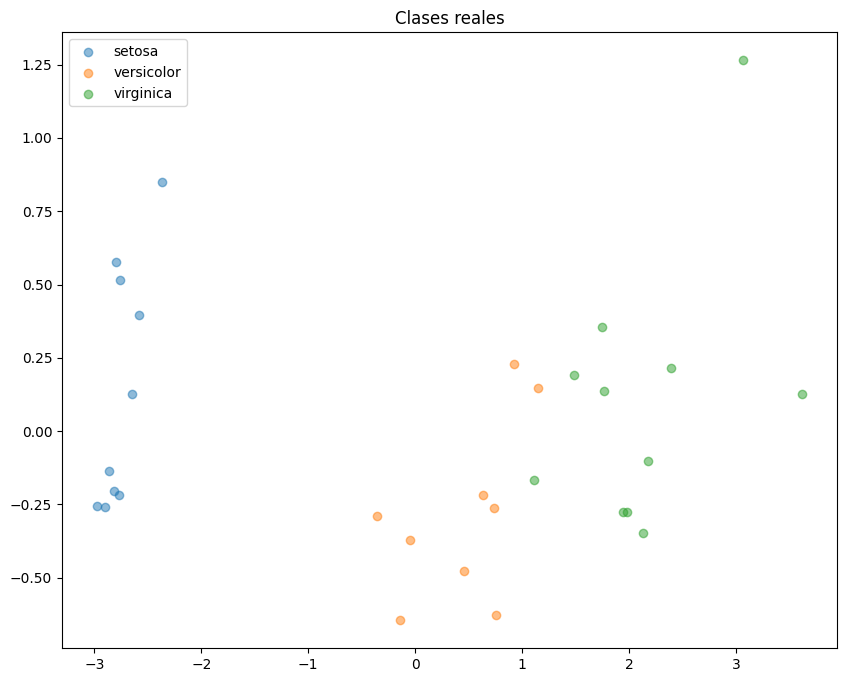

In [48]:
# Graficar las observaciones según su clase real y predicha
plt.figure(figsize=(10,8))
for i in range(len(iris.target_names)):
    plt.scatter(X_pca[y_test == i, 0], X_pca[y_test == i, 1], label=iris.target_names[i], alpha=0.5)
plt.title('Clases reales')
plt.legend()
plt.show()

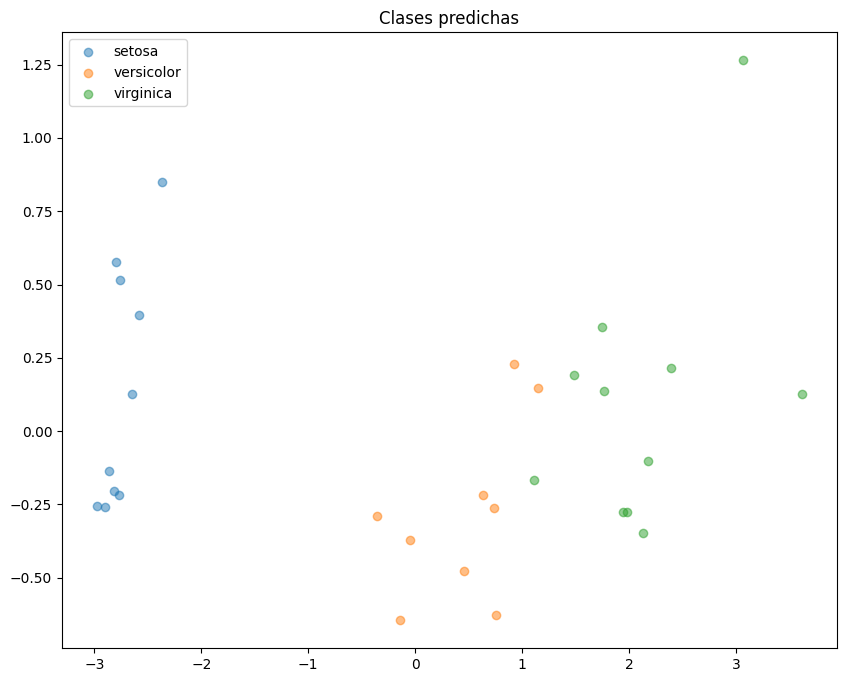

In [49]:
plt.figure(figsize=(10,8))
for i in range(len(iris.target_names)):
    plt.scatter(X_pca[y_pred == i, 0], X_pca[y_pred == i, 1], label=iris.target_names[i], alpha=0.5)
plt.title('Clases predichas')
plt.legend()
plt.show()

In [50]:
# la matriz de confusion
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

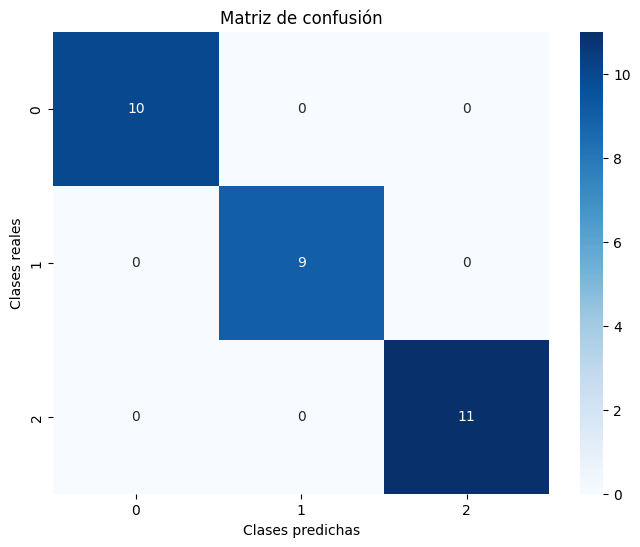

In [ ]:
# Graficar la matriz de confusión
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Clases predichas')
plt.ylabel('Clases reales')
plt.title('Matriz de confusión')
plt.show()

In [ ]:
# las filas representan las clase reales
# las columnas representan las clases predichas
# la diagonal principal indica el num de predicciones correctas para cada clase
# los valores fuera de la diagonal indican los errores de clasificacion
# (falsos positivos y falsos negativos)